In [30]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [ ]:
df = pd.read_csv(r"C:\Users\obito\OneDrive\Desktop\deep learning\student-mat.csv", sep=";")

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [33]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [34]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [35]:
X = df.drop("G3", axis=1)
y = df["G3"]



In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])


In [39]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train_scaled,y_train,epochs=100,batch_size=32,validation_split=0.2,verbose=1)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 117.0524 - mae: 9.8429 - val_loss: 108.9613 - val_mae: 9.7333
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 103.2817 - mae: 9.2623 - val_loss: 94.1024 - val_mae: 9.0571
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 87.8565 - mae: 8.5439 - val_loss: 76.9975 - val_mae: 8.1885
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 70.5970 - mae: 7.6460 - val_loss: 58.3276 - val_mae: 7.0949
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 52.1758 - mae: 6.5084 - val_loss: 39.7351 - val_mae: 5.8030
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 35.4120 - mae: 5.2004 - val_loss: 24.0354 - val_mae: 4.3906
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 22.5415 - mae: 3.9717 - val_loss: 14.5284 - val_mae: 3.1305
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 16.2714 - mae: 3.1981 - val_loss: 11.3548 - val_mae: 2.3116
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - l

In [41]:
loss, mae = model.evaluate(X_test_scaled, y_test)
print("\nTest MSE:", loss)
print("Test MAE:", mae)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 8.8267 - mae: 2.0177 

Test MSE: 8.826702117919922
Test MAE: 2.0177090167999268


In [42]:
y_pred = model.predict(X_test_scaled)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


In [43]:
print("\nSample Predictions")
for i in range(10):
    print(f"Actual: {y_test.iloc[i]} | Predicted: {y_pred[i][0]:.2f}")


Sample Predictions
Actual: 10 | Predicted: 6.51
Actual: 12 | Predicted: 11.73
Actual: 5 | Predicted: 2.76
Actual: 10 | Predicted: 10.08
Actual: 9 | Predicted: 11.16
Actual: 13 | Predicted: 9.90
Actual: 18 | Predicted: 19.22
Actual: 6 | Predicted: 9.09
Actual: 0 | Predicted: 5.94
Actual: 14 | Predicted: 11.58


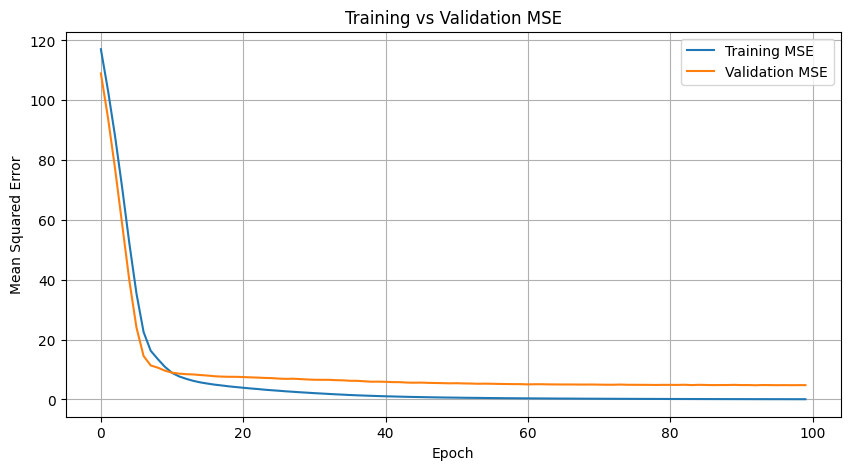

In [44]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training MSE')
plt.plot(history.history['val_loss'], label='Validation MSE')
plt.title('Training vs Validation MSE')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

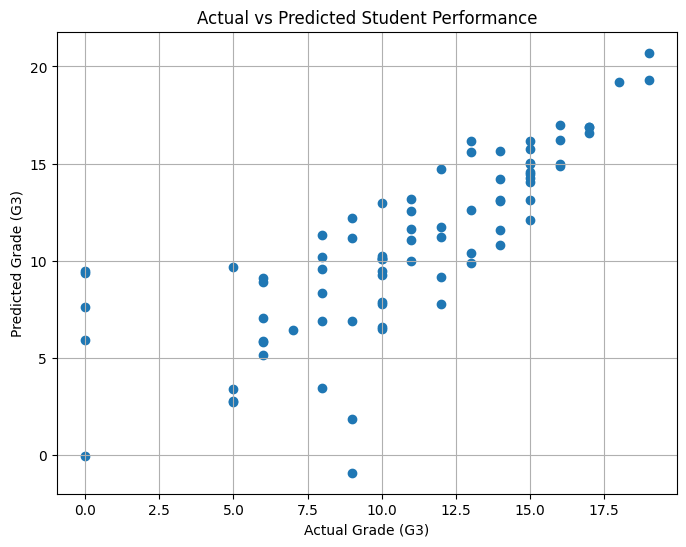

In [45]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Grade (G3)")
plt.ylabel("Predicted Grade (G3)")
plt.title("Actual vs Predicted Student Performance")
plt.grid(True)
plt.show()

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 4709.6162 - mae: 67.0518 
Test Accuracy: 67.05181884765625
